In [ ]:
import numpy as np
from scipy.stats import norm

# First we need the greek calculations
def black_scholes_gamma(S, K, T, r, sigma, option_type='call'):
    """Calculate gamma for an option"""
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    return gamma

def calculate_gex(gamma, open_interest, spot_price, notional=1):
    """Calculate Gamma Exposure"""
    # GEX = Gamma × Open Interest × Spot^2 × Notional
    return gamma * open_interest * (spot_price ** 2) * notional * 0.01

In [2]:
def net_gex_by_strike(options_data, spot_price):
    """
    Calculate net GEX (calls - puts) for each strike
    Dealers are short gamma when they sell options
    """
    gex_by_strike = {}
    
    for option in options_data:
        strike = option['strike']
        oi = option['open_interest']
        iv = option['iv']
        time_to_expiry = option['tte']
        is_call = option['type'] == 'call'
        
        # Calculate gamma
        gamma = black_scholes_gamma(
            spot_price, strike, time_to_expiry, 0.0, iv
        )
        
        # Calculate GEX (dealers are short, so flip sign)
        gex = -calculate_gex(gamma, oi, spot_price)
        
        # Calls are positive gamma for dealers when price rises
        # Puts are negative gamma for dealers when price rises
        multiplier = 1 if is_call else -1
        
        if strike not in gex_by_strike:
            gex_by_strike[strike] = 0
        gex_by_strike[strike] += gex * multiplier
    
    return gex_by_strike

In [3]:
def find_gamma_flip(gex_by_strike):
    """Find where net GEX crosses zero"""
    strikes = sorted(gex_by_strike.keys())
    
    for i in range(len(strikes)-1):
        current_gex = gex_by_strike[strikes[i]]
        next_gex = gex_by_strike[strikes[i+1]]
        
        if current_gex * next_gex < 0:  # Sign change
            return (strikes[i] + strikes[i+1]) / 2
    return None

In [4]:
def identify_trap_levels(gex_by_strike, threshold_percentile=90):
    """Identify strikes with high absolute GEX"""
    gex_values = list(gex_by_strike.values())
    threshold = np.percentile(np.abs(gex_values), threshold_percentile)
    
    trap_levels = {
        strike: gex for strike, gex in gex_by_strike.items()
        if abs(gex) > threshold
    }
    return trap_levels

In [5]:
def estimate_dealer_delta_hedging(spot_change, gex_by_strike, current_spot):
    """Estimate dealer hedging flow for a spot move"""
    total_delta_hedge = 0
    
    for strike, gex in gex_by_strike.items():
        # Approximate delta change = gamma × spot change
        delta_change = (gex / (current_spot ** 2)) * spot_change
        total_delta_hedge += delta_change
    
    return total_delta_hedge

In [7]:
import matplotlib.pyplot as plt

def plot_gex_profile(gex_by_strike, current_spot, gamma_flip=None):
    strikes = sorted(gex_by_strike.keys())
    gex_values = [gex_by_strike[s] for s in strikes]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Color code bars
    colors = ['blue' if gex > 0 else 'red' for gex in gex_values]
    ax.bar(strikes, gex_values, color=colors, alpha=0.6)
    
    # Mark current spot
    ax.axvline(current_spot, color='black', linestyle='--', 
               label=f'Spot: ${current_spot:,.0f}')
    
    # Mark gamma flip
    if gamma_flip:
        ax.axvline(gamma_flip, color='green', linestyle='--',
                   label=f'Gamma Flip: ${gamma_flip:,.0f}')
    
    ax.set_xlabel('Strike Price')
    ax.set_ylabel('Net Gamma Exposure (GEX)')
    ax.set_title('BTC Net Gamma Exposure Profile')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

Fetching BTC options data from Deribit...
Current BTC Spot Price: $93,950.50
Total options contracts: 618
Total open interest: 284,508

Calculating Net Gamma Exposure...
No Gamma Flip Found

Trap Levels (High GEX strikes):
  strike           gex
 94000.0 -3.368071e+07
 95000.0 -4.383875e+07
 96000.0 -2.472132e+07
100000.0 -4.166436e+07

Generating charts...


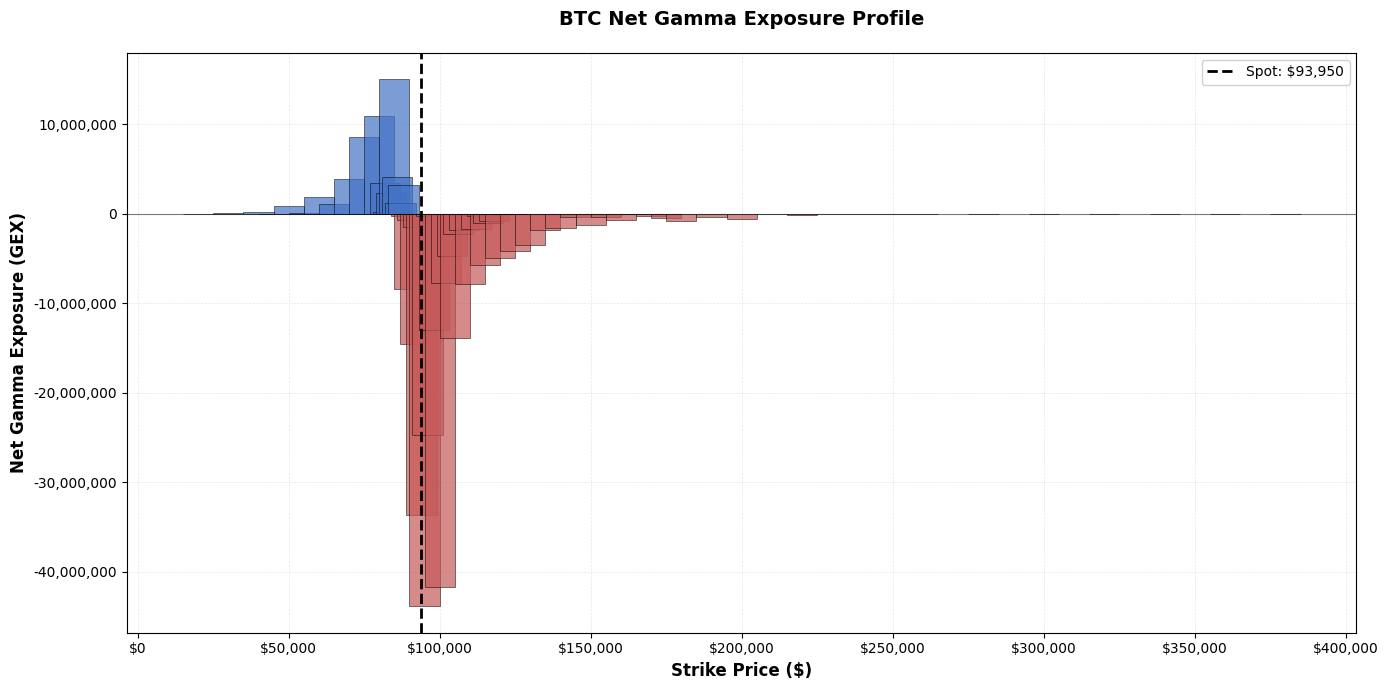

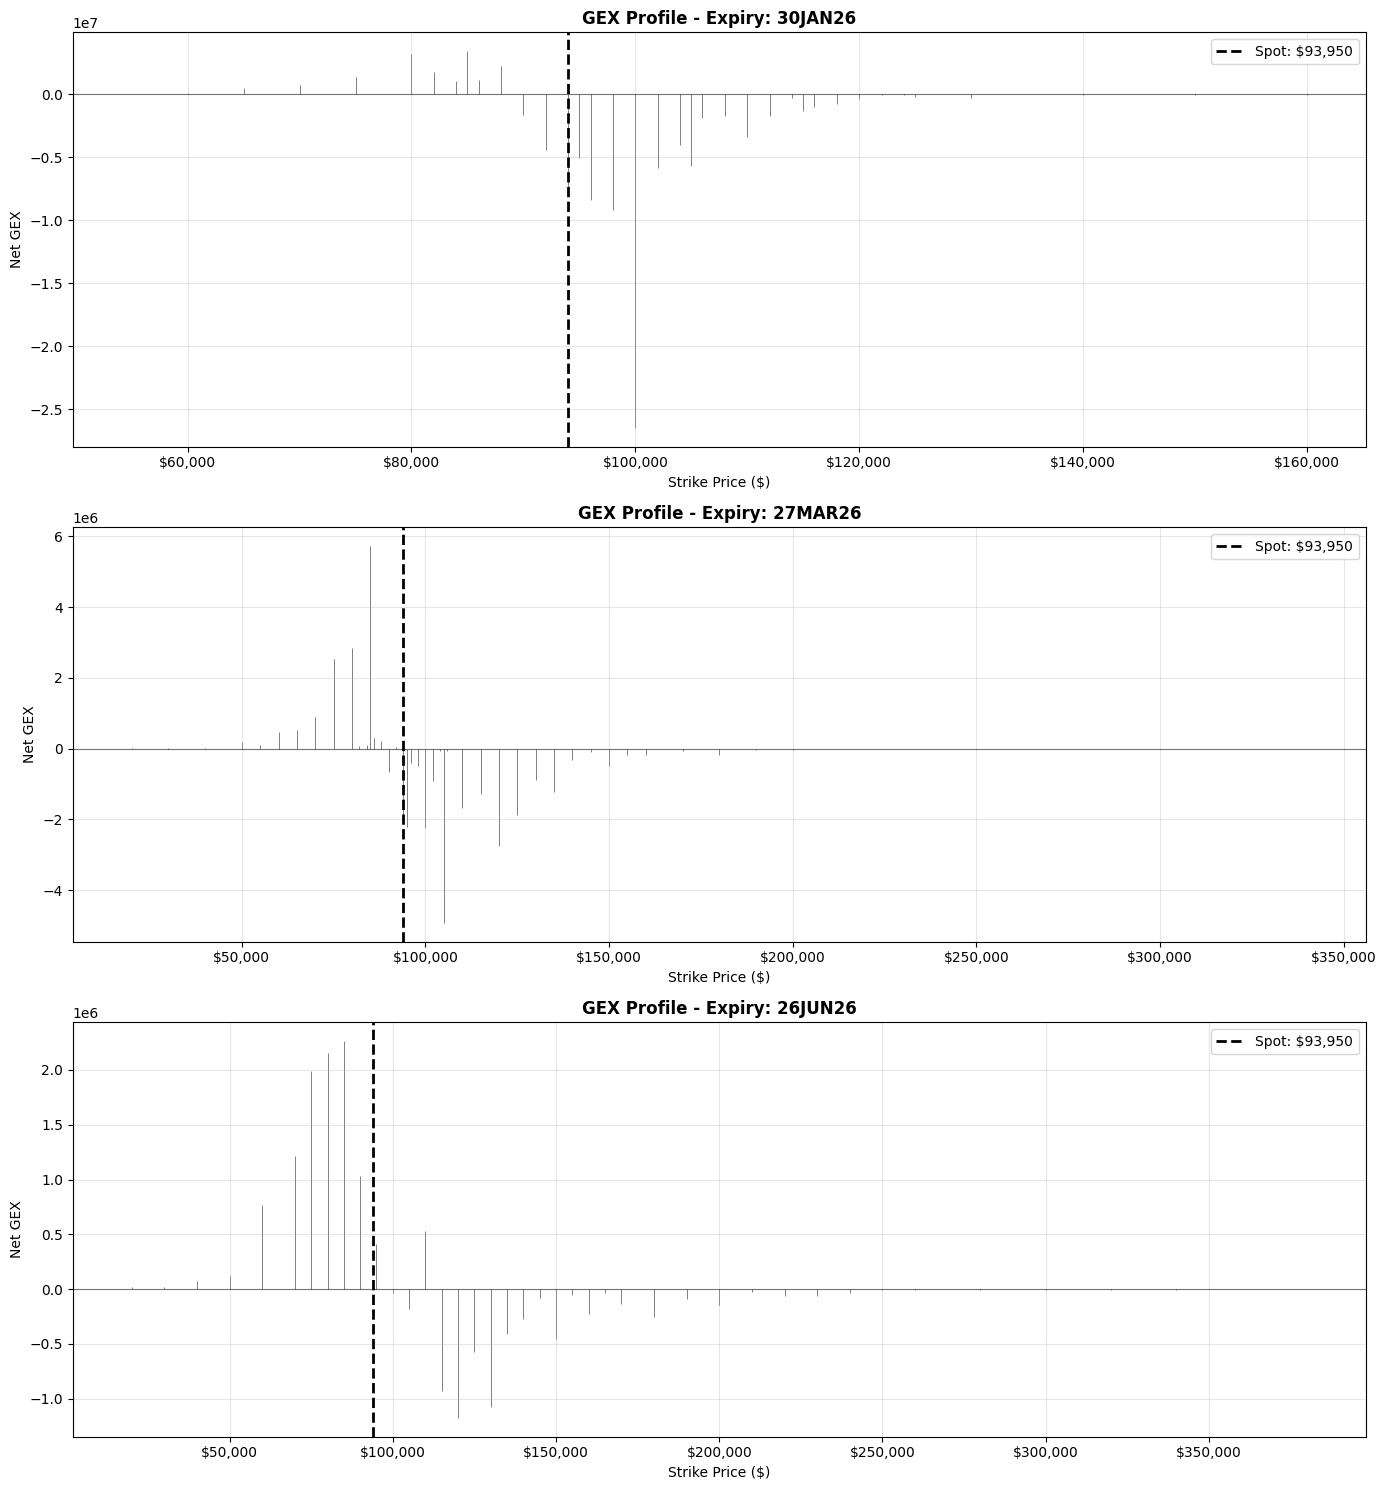


Charts saved!


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from datetime import datetime, timedelta
import requests

# ============================================================================
# 1. FETCH DATA FROM DERIBIT
# ============================================================================

def fetch_deribit_options_data(currency='BTC'):
    """Fetch BTC options data from Deribit"""
    
    # Get current price
    ticker_url = f"https://www.deribit.com/api/v2/public/ticker?instrument_name={currency}-PERPETUAL"
    response = requests.get(ticker_url)
    spot_price = response.json()['result']['last_price']
    
    # Get all instruments
    instruments_url = f"https://www.deribit.com/api/v2/public/get_instruments?currency={currency}&kind=option&expired=false"
    response = requests.get(instruments_url)
    instruments = response.json()['result']
    
    options_data = []
    
    for instrument in instruments:
        instrument_name = instrument['instrument_name']
        
        # Get book summary for open interest and IV
        book_url = f"https://www.deribit.com/api/v2/public/get_book_summary_by_instrument?instrument_name={instrument_name}"
        book_response = requests.get(book_url)
        book_data = book_response.json()['result'][0]
        
        # Parse instrument name: BTC-28MAR25-80000-C
        parts = instrument_name.split('-')
        strike = float(parts[2])
        option_type = 'call' if parts[3] == 'C' else 'put'
        expiry_str = parts[1]
        
        # Calculate time to expiry
        expiry_date = datetime.strptime(expiry_str, '%d%b%y')
        tte = (expiry_date - datetime.now()).days / 365.0
        
        if tte <= 0:
            continue
        
        options_data.append({
            'strike': strike,
            'type': option_type,
            'expiry': expiry_str,
            'tte': tte,
            'open_interest': book_data.get('open_interest', 0),
            'iv': book_data.get('mark_iv', 0) / 100,  # Convert to decimal
            'volume': book_data.get('volume', 0)
        })
    
    return pd.DataFrame(options_data), spot_price

# ============================================================================
# 2. CALCULATE GREEKS
# ============================================================================

def calculate_gamma(S, K, T, r, sigma):
    """
    Calculate Gamma using Black-Scholes formula
    
    S: Spot price
    K: Strike price
    T: Time to expiry (years)
    r: Risk-free rate
    sigma: Implied volatility
    """
    if T <= 0 or sigma <= 0:
        return 0
    
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    
    return gamma

# ============================================================================
# 3. CALCULATE NET GEX
# ============================================================================

def calculate_net_gex(options_df, spot_price, risk_free_rate=0.0):
    """
    Calculate Net Gamma Exposure for each strike
    
    Dealer perspective:
    - When dealers SELL options, they are SHORT gamma
    - Calls: Positive GEX (dealers need to buy when price rises)
    - Puts: Negative GEX (dealers need to sell when price rises)
    """
    
    gex_data = []
    
    for _, option in options_df.iterrows():
        if option['open_interest'] == 0:
            continue
        
        # Calculate gamma
        gamma = calculate_gamma(
            S=spot_price,
            K=option['strike'],
            T=option['tte'],
            r=risk_free_rate,
            sigma=option['iv']
        )
        
        # GEX formula: Gamma × OI × Spot^2 × 0.01
        # Multiply by 0.01 to convert to notional per 1% move
        gex = gamma * option['open_interest'] * (spot_price ** 2) * 0.01
        
        # Dealer is short gamma (sold options to customers)
        # So we flip the sign
        gex = -gex
        
        # Calls have positive GEX, Puts have negative GEX from dealer perspective
        if option['type'] == 'put':
            gex = -gex
        
        gex_data.append({
            'strike': option['strike'],
            'gex': gex,
            'type': option['type'],
            'oi': option['open_interest'],
            'expiry': option['expiry']
        })
    
    gex_df = pd.DataFrame(gex_data)
    
    # Aggregate by strike (sum across all expiries)
    net_gex = gex_df.groupby('strike')['gex'].sum().reset_index()
    net_gex = net_gex.sort_values('strike')
    
    return net_gex, gex_df

# ============================================================================
# 4. FIND KEY LEVELS
# ============================================================================

def find_gamma_flip(net_gex_df):
    """Find the strike where GEX crosses from negative to positive"""
    
    for i in range(len(net_gex_df) - 1):
        current_gex = net_gex_df.iloc[i]['gex']
        next_gex = net_gex_df.iloc[i + 1]['gex']
        
        if current_gex < 0 and next_gex > 0:
            # Linear interpolation for more accurate flip point
            current_strike = net_gex_df.iloc[i]['strike']
            next_strike = net_gex_df.iloc[i + 1]['strike']
            
            flip_point = current_strike + (next_strike - current_strike) * \
                        (abs(current_gex) / (abs(current_gex) + abs(next_gex)))
            
            return flip_point
    
    return None

def find_trap_levels(net_gex_df, threshold_percentile=90):
    """Find strikes with high absolute GEX (potential support/resistance)"""
    
    threshold = net_gex_df['gex'].abs().quantile(threshold_percentile / 100)
    trap_levels = net_gex_df[net_gex_df['gex'].abs() > threshold]
    
    return trap_levels

# ============================================================================
# 5. VISUALIZATION
# ============================================================================

def plot_gex_profile(net_gex_df, spot_price, gamma_flip=None, title="BTC Net Gamma Exposure Profile"):
    """
    Create a bar chart of Net GEX vs Strike Price
    """
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Prepare data
    strikes = net_gex_df['strike'].values
    gex_values = net_gex_df['gex'].values
    
    # Color bars: Blue for positive (call wall), Red for negative (put wall)
    colors = ['#4472C4' if gex > 0 else '#C55A5A' for gex in gex_values]
    
    # Create bar chart
    bars = ax.bar(strikes, gex_values, width=strikes[1]-strikes[0] if len(strikes) > 1 else 1000, 
                  color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
    
    # Add current spot price line
    ax.axvline(spot_price, color='black', linestyle='--', linewidth=2, 
               label=f'Spot: ${spot_price:,.0f}', zorder=5)
    
    # Add gamma flip line
    if gamma_flip:
        ax.axvline(gamma_flip, color='green', linestyle='--', linewidth=2,
                   label=f'Gamma Flip: ${gamma_flip:,.0f}', zorder=5)
        
        # Add shaded regions
        ax.axvspan(strikes.min(), gamma_flip, alpha=0.1, color='red', 
                   label='Negative Gamma Zone')
        ax.axvspan(gamma_flip, strikes.max(), alpha=0.1, color='blue',
                   label='Positive Gamma Zone')
    
    # Formatting
    ax.set_xlabel('Strike Price ($)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Net Gamma Exposure (GEX)', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    # Grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)
    
    # Legend
    ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
    
    # Format y-axis
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    
    # Add zero line
    ax.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.5)
    
    plt.tight_layout()
    return fig

def plot_gex_by_expiry(gex_df, spot_price, expiries_to_plot=None):
    """Plot GEX separated by expiry date"""
    
    if expiries_to_plot is None:
        # Get top 3 expiries by total OI
        top_expiries = gex_df.groupby('expiry')['oi'].sum().nlargest(3).index.tolist()
        expiries_to_plot = top_expiries
    
    fig, axes = plt.subplots(len(expiries_to_plot), 1, figsize=(14, 5*len(expiries_to_plot)))
    
    if len(expiries_to_plot) == 1:
        axes = [axes]
    
    for idx, expiry in enumerate(expiries_to_plot):
        expiry_data = gex_df[gex_df['expiry'] == expiry]
        net_gex_expiry = expiry_data.groupby('strike')['gex'].sum().reset_index()
        
        ax = axes[idx]
        strikes = net_gex_expiry['strike'].values
        gex_values = net_gex_expiry['gex'].values
        
        colors = ['#4472C4' if gex > 0 else '#C55A5A' for gex in gex_values]
        ax.bar(strikes, gex_values, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
        
        ax.axvline(spot_price, color='black', linestyle='--', linewidth=2, label=f'Spot: ${spot_price:,.0f}')
        ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
        
        ax.set_title(f'GEX Profile - Expiry: {expiry}', fontweight='bold')
        ax.set_xlabel('Strike Price ($)')
        ax.set_ylabel('Net GEX')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    
    plt.tight_layout()
    return fig

# ============================================================================
# 6. MAIN EXECUTION
# ============================================================================

def main():
    print("Fetching BTC options data from Deribit...")
    
    # Fetch data
    options_df, spot_price = fetch_deribit_options_data('BTC')
    
    print(f"Current BTC Spot Price: ${spot_price:,.2f}")
    print(f"Total options contracts: {len(options_df)}")
    print(f"Total open interest: {options_df['open_interest'].sum():,.0f}")
    
    # Calculate GEX
    print("\nCalculating Net Gamma Exposure...")
    net_gex_df, gex_detail_df = calculate_net_gex(options_df, spot_price)
    
    # Find key levels
    gamma_flip = find_gamma_flip(net_gex_df)
    trap_levels = find_trap_levels(net_gex_df, threshold_percentile=95)
    
    print(f"\nGamma Flip Level: ${gamma_flip:,.2f}" if gamma_flip else "No Gamma Flip Found")
    print(f"\nTrap Levels (High GEX strikes):")
    print(trap_levels[['strike', 'gex']].to_string(index=False))
    
    # Plot
    print("\nGenerating charts...")
    
    # Main GEX chart
    fig1 = plot_gex_profile(net_gex_df, spot_price, gamma_flip)
    plt.savefig('btc_gex_profile.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # GEX by expiry
    fig2 = plot_gex_by_expiry(gex_detail_df, spot_price)
    plt.savefig('btc_gex_by_expiry.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nCharts saved!")
    
    return net_gex_df, gex_detail_df, spot_price

# ============================================================================
# RUN
# ============================================================================

if __name__ == "__main__":
    net_gex_df, gex_detail_df, spot_price = main()